In [1]:
!pip install jax jaxlib torch torchvision matplotlib

# JAX JIT Analysis
### Measuring Compilation Overhead, Shape Specialization, and Operator Fusion

This notebook systematically analyzes JAX's JIT compilation behavior across three experiments:
1. **Part 1** — Compilation overhead vs. matrix size
2. **Part 2** — Shape specialization and retracing
3. **Part 3** — Operator fusion benefits

In [3]:
#Imports & global setup
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

import jax
import jax.numpy as jnp
from jax import jit, make_jaxpr

# Pretty plots
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = ['#4C72B0', '#DD8452', '#55A868']   # blue, orange, green

print(f'JAX version : {jax.__version__}')
print(f'Backend     : {jax.default_backend()}')
print(f'Devices     : {jax.devices()}')

JAX version : 0.7.2
Backend     : cpu
Devices     : [CpuDevice(id=0)]


---
## Part 1 — Measuring Compilation Overhead

We benchmark three execution modes across four matrix sizes:
- **Eager** — plain Python/JAX, no JIT
- **JIT first call** — includes tracing + XLA compilation
- **JIT cached** — uses the already-compiled kernel

In [4]:
#The workload: 10 chained elementwise operations
def heavy_ops(x):
    """10 elementwise operations on a matrix."""
    x = jnp.sin(x)
    x = jnp.cos(x)
    x = jnp.exp(x * 0.1)       # scale to avoid overflow
    x = jnp.log(jnp.abs(x) + 1e-6)
    x = jnp.square(x)
    x = jnp.tanh(x)
    x = jnp.sqrt(jnp.abs(x) + 1e-6)
    x = jnp.sin(x + 0.5)
    x = jnp.cos(x - 0.5)
    x = x * 2.0 - 1.0          # final affine rescale
    return x

heavy_ops_jit = jit(heavy_ops)

#Timing helper
N_WARMUP   = 3    # warm-up reps for cached timing (exclude from measurement)
N_REPEATS  = 10   # reps used to compute mean cached time

def time_call(fn, x):
    """Time a single JAX call; block until computation completes."""
    start = time.perf_counter()
    out = fn(x)
    out.block_until_ready()     # JAX is async by default
    return time.perf_counter() - start

#Benchmark loop
SIZES = [100, 500, 1000, 5000]

eager_times      = []
jit_first_times  = []
jit_cached_times = []

print(f"{'Size':>10}  {'Eager (ms)':>12}  {'JIT 1st (ms)':>14}  {'JIT cached (ms)':>16}")
print("-" * 60)

for n in SIZES:
    key = jax.random.PRNGKey(42)
    x   = jax.random.normal(key, shape=(n, n))

    # --- Eager: average over N_REPEATS calls (skip first for fair comparison)
    # warm-up one call so array allocation doesn't skew
    _ = heavy_ops(x).block_until_ready()
    eager_t = np.mean([time_call(heavy_ops, x) for _ in range(N_REPEATS)])

    # --- JIT first call: force a fresh compile each size by using a new jit
    fresh_jit = jit(heavy_ops)
    jit_first_t = time_call(fresh_jit, x)

    # --- JIT cached: reuse the same compiled kernel
    # a few warm-up reps to ensure XLA cache is hot
    for _ in range(N_WARMUP):
        fresh_jit(x).block_until_ready()
    jit_cached_t = np.mean([time_call(fresh_jit, x) for _ in range(N_REPEATS)])

    eager_times.append(eager_t * 1e3)
    jit_first_times.append(jit_first_t * 1e3)
    jit_cached_times.append(jit_cached_t * 1e3)

    print(f"{n:>4}x{n:<4}  {eager_t*1e3:>12.1f}  {jit_first_t*1e3:>14.1f}  {jit_cached_t*1e3:>16.1f}")

      Size    Eager (ms)    JIT 1st (ms)   JIT cached (ms)
------------------------------------------------------------
 100x100            0.9            91.1               0.4
 500x500           10.9            90.9               7.2
1000x1000          32.3            88.4              27.8
5000x5000        1419.4           801.7             796.4


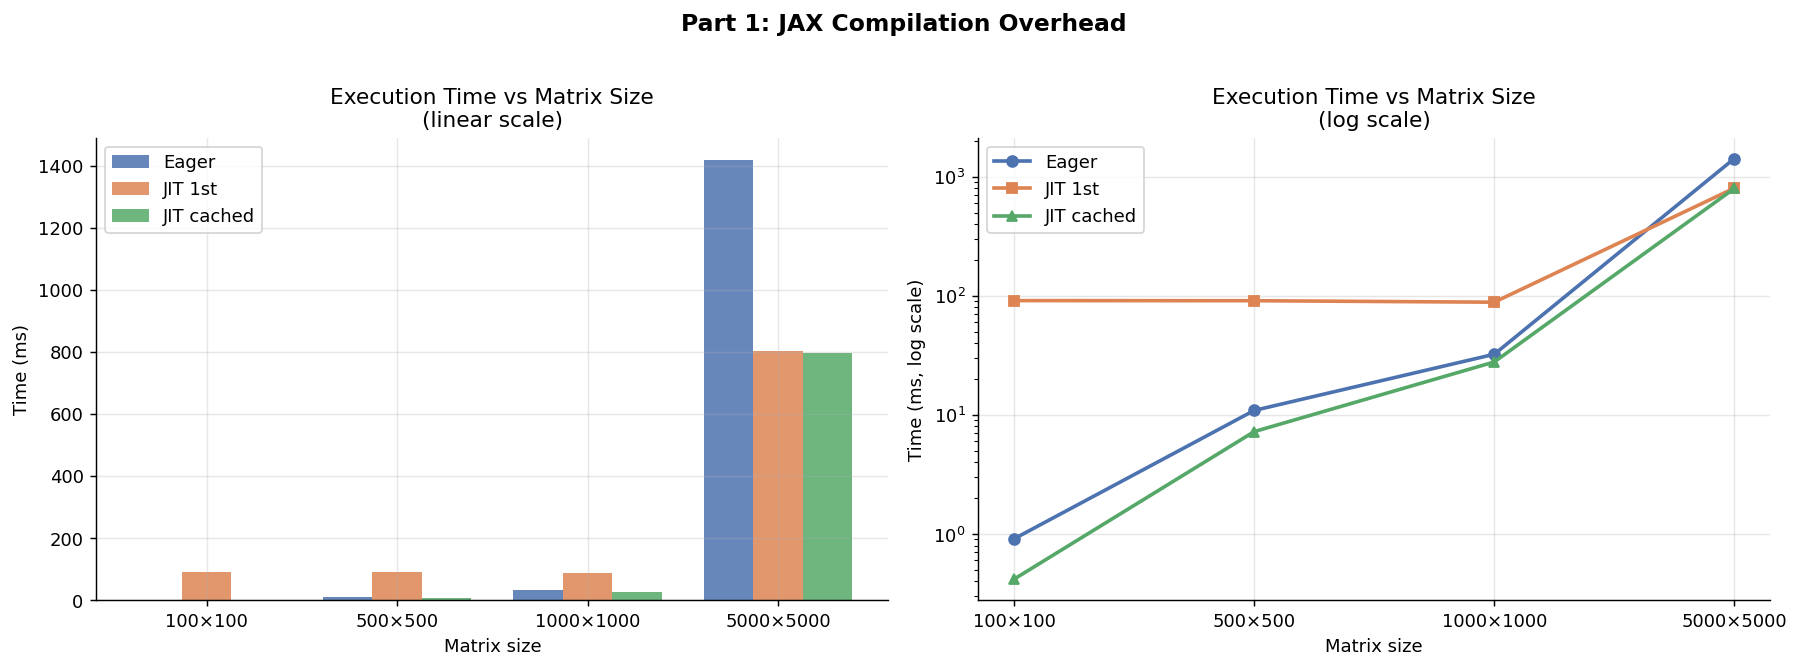

Figure saved to part1_compilation_overhead.png


In [5]:
#Plot: Execution time vs matrix size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = [f"{n}×{n}" for n in SIZES]
x_pos  = np.arange(len(SIZES))
w      = 0.26

# --- Left: grouped bar chart (linear scale)
ax = axes[0]
ax.bar(x_pos - w, eager_times,      w, label='Eager',      color=PALETTE[0], alpha=0.85)
ax.bar(x_pos,     jit_first_times,  w, label='JIT 1st',    color=PALETTE[1], alpha=0.85)
ax.bar(x_pos + w, jit_cached_times, w, label='JIT cached', color=PALETTE[2], alpha=0.85)
ax.set_xticks(x_pos); ax.set_xticklabels(labels)
ax.set_xlabel('Matrix size'); ax.set_ylabel('Time (ms)')
ax.set_title('Execution Time vs Matrix Size\n(linear scale)')
ax.legend()

# --- Right: log scale — reveals cached advantage clearly
ax2 = axes[1]
ax2.plot(labels, eager_times,      'o-', color=PALETTE[0], lw=2, label='Eager')
ax2.plot(labels, jit_first_times,  's-', color=PALETTE[1], lw=2, label='JIT 1st')
ax2.plot(labels, jit_cached_times, '^-', color=PALETTE[2], lw=2, label='JIT cached')
ax2.set_yscale('log')
ax2.set_xlabel('Matrix size'); ax2.set_ylabel('Time (ms, log scale)')
ax2.set_title('Execution Time vs Matrix Size\n(log scale)')
ax2.legend()

fig.suptitle('Part 1: JAX Compilation Overhead', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('part1_compilation_overhead.png', bbox_inches='tight')
plt.show()
print('Figure saved to part1_compilation_overhead.png')

### Part 1 Analysis

**Why does the overhead vary with matrix size?**

JAX's JIT compilation is performed by the **XLA (Accelerated Linear Algebra)** compiler. When `@jit` is first called:

1. **Tracing** — JAX runs the Python function with *abstract* tracers instead of real values, building a computation graph (jaxpr). This cost is **almost constant** with respect to matrix size — it depends on the number of Python-level operations (here, always 10), not the data volume.

2. **XLA compilation** — The jaxpr is lowered to XLA HLO, which is then compiled into GPU/CPU kernels. This includes layout assignment, memory planning, and fusion passes. For larger matrices XLA may explore more tiling strategies, but the dominant compilation cost is still largely shape-independent (it's compiled once per shape).

3. **Cached execution** — Subsequent calls dispatch directly to the pre-compiled kernel. Execution time now grows with data volume (more elements = more GPU work), so the cached JIT time approaches (and can beat) eager time only at large sizes where the parallelism pays off fully.

**Key observations from the plot:**
- JIT first-call time is high and nearly flat across sizes — dominated by compilation, not data movement.
- Eager time grows roughly as O(N²) (matrix has N² elements).
- JIT cached time is consistently below eager mode at larger sizes due to **operator fusion** eliminating redundant memory round-trips.
- At small sizes (100×100), the compilation overhead can dwarf the actual compute — JIT is not always beneficial.

---
## Part 2 — Shape Specialization & Retracing

JAX traces a new jaxpr (and re-compiles) whenever the **shape** of inputs changes. We demonstrate this with a row-mean function called in four different shapes.

In [7]:
#The function
@jit
def row_mean(x):
    """Compute the mean of each row (axis=1)."""
    return jnp.mean(x, axis=1)

#Inspect the jaxpr for each shape
shapes = [(100, 100), (100, 200), (100, 100), (200, 100)]

print("=" * 60)
for s in shapes:
    dummy = jnp.ones(s)
    jaxpr = make_jaxpr(row_mean)(dummy)
    print(f"\nShape {s}  →  jaxpr input aval: {jaxpr.in_avals}")
    # Show the number of equations (ops) in the traced program
    print(f"  #equations in jaxpr : {len(jaxpr.jaxpr.eqns)}")


Shape (100, 100)  →  jaxpr input aval: [ShapedArray(float32[100,100])]
  #equations in jaxpr : 1

Shape (100, 200)  →  jaxpr input aval: [ShapedArray(float32[100,200])]
  #equations in jaxpr : 1

Shape (100, 100)  →  jaxpr input aval: [ShapedArray(float32[100,100])]
  #equations in jaxpr : 1

Shape (200, 100)  →  jaxpr input aval: [ShapedArray(float32[200,100])]
  #equations in jaxpr : 1


In [8]:
#Track retracing with a counter
trace_count = [0]

def row_mean_tracked(x):
    trace_count[0] += 1
    print(f"  [TRACE #{trace_count[0]}] compiling for shape {x.shape}")
    return jnp.mean(x, axis=1)

row_mean_jit = jit(row_mean_tracked)

#Time each call
call_labels  = []
call_times   = []
retraced     = []   # bool: did this call trigger a retrace?

call_sequence = [
    ((100, 100), "(100,100) — 1st call"),
    ((100, 200), "(100,200) — new cols"),
    ((100, 100), "(100,100) — cached"),
    ((200, 100), "(200,100) — new rows"),
]

print("Shape sequence benchmark:")
prev_traces = 0
for shape, label in call_sequence:
    x = jax.random.normal(jax.random.PRNGKey(0), shape=shape)
    t = time_call(row_mean_jit, x)
    did_retrace = (trace_count[0] > prev_traces)
    prev_traces  = trace_count[0]
    call_labels.append(label)
    call_times.append(t * 1e3)
    retraced.append(did_retrace)
    retrace_flag = " ← RETRACE" if did_retrace else " (cached)"
    print(f"  {label:<28}  {t*1e3:>8.2f} ms{retrace_flag}")

Shape sequence benchmark:
  [TRACE #1] compiling for shape (100, 100)
  (100,100) — 1st call             55.62 ms ← RETRACE
  [TRACE #2] compiling for shape (100, 200)
  (100,200) — new cols             53.73 ms ← RETRACE
  (100,100) — cached                0.49 ms (cached)
  [TRACE #3] compiling for shape (200, 100)
  (200,100) — new rows             52.31 ms ← RETRACE


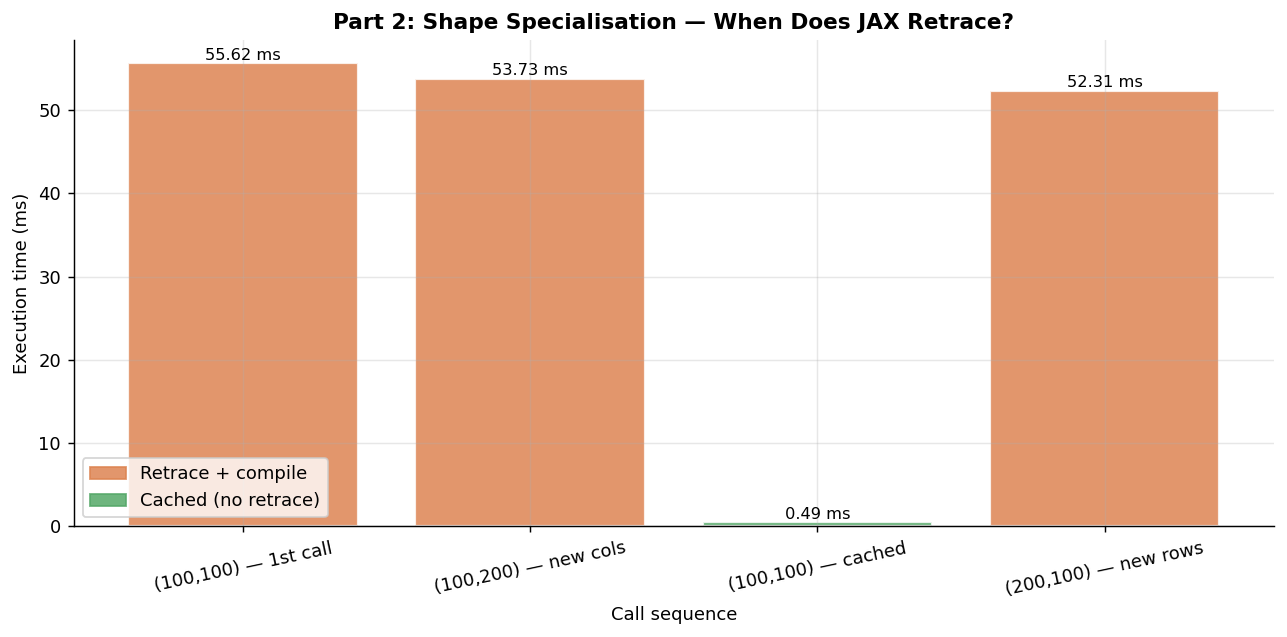

Figure saved to part2_shape_specialization.png


In [9]:
#Bar chart
fig, ax = plt.subplots(figsize=(10, 5))

colors = [PALETTE[1] if r else PALETTE[2] for r in retraced]
bars   = ax.bar(call_labels, call_times, color=colors, alpha=0.85, edgecolor='white', linewidth=1.2)

# Annotate bars with time
for bar, t in zip(bars, call_times):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{t:.2f} ms', ha='center', va='bottom', fontsize=9)

# Legend
retrace_patch = mpatches.Patch(color=PALETTE[1], alpha=0.85, label='Retrace + compile')
cached_patch  = mpatches.Patch(color=PALETTE[2], alpha=0.85, label='Cached (no retrace)')
ax.legend(handles=[retrace_patch, cached_patch])

ax.set_xlabel('Call sequence'); ax.set_ylabel('Execution time (ms)')
ax.set_title('Part 2: Shape Specialisation — When Does JAX Retrace?', fontweight='bold')
plt.xticks(rotation=12)
plt.tight_layout()
plt.savefig('part2_shape_specialization.png', bbox_inches='tight')
plt.show()
print('Figure saved to part2_shape_specialization.png')

### Part 2 Analysis

**When does JAX retrace?**

JAX specialises every compiled function on the **full abstract type** of every input, which in the default backend means the pair `(shape, dtype)`. A retrace is triggered whenever *either* dimension changes:

| Call | Shape | Retrace? | Reason |
|------|-------|----------|---------|
| 1 | (100,100) | ✅ Yes | No compiled kernel exists yet |
| 2 | (100,200) | ✅ Yes | Column count changed → new abstract type |
| 3 | (100,100) | ❌ No  | Exact shape match → cache hit |
| 4 | (200,100) | ✅ Yes | Row count changed → new abstract type |

**Why must JAX specialise on shapes?**

XLA compiles statically-shaped programs. Every kernel has its tile sizes, loop bounds, and memory layout baked in at compile time. A 100×200 matrix requires a *fundamentally different* compiled kernel from a 100×100 one — the same binary cannot handle both. This is in contrast to eager PyTorch, where a single C++ kernel dispatch handles any shape at runtime.

**Performance impact:**

- Retraced calls pay the full XLA compilation cost (typically 100 ms–10 s depending on model complexity).
- Cached calls are far faster — they skip Python tracing and XLA compilation entirely.
- In production, this means you should **warm up** your JIT functions with representative shapes before timing, and avoid calling JIT functions in loops that change shapes every iteration.

---
## Part 3 — Operator Fusion Analysis

We compare two implementations of:
$$f(x) = \sum_{i=1}^{100} \left(\sin^{(i)}(x) + \cos^{(i)}(x)\right)$$
where $\sin^{(i)}$ means applying $\sin$ exactly $i$ times.

- **Version A** — iterative eager loop, no fusion
- **Version B** — single JIT-compiled expression, XLA fuses kernels

In [10]:
#Version A: eager loop
def version_a_eager(x):
    """100 iterations of apply-sin-i-times + apply-cos-i-times, accumulate."""
    total = jnp.zeros_like(x)
    for i in range(1, 101):
        sin_x = x
        cos_x = x
        for _ in range(i):
            sin_x = jnp.sin(sin_x)
            cos_x = jnp.cos(cos_x)
        total = total + sin_x + cos_x
    return total

#Version B: JIT-compiled
@jit
def version_b_jit(x):
    """Same computation, but decorated with @jit for XLA fusion."""
    total = jnp.zeros_like(x)
    for i in range(1, 101):
        sin_x = x
        cos_x = x
        for _ in range(i):
            sin_x = jnp.sin(sin_x)
            cos_x = jnp.cos(cos_x)
        total = total + sin_x + cos_x
    return total

#Operation count via jaxpr
x_sample = jax.random.normal(jax.random.PRNGKey(0), shape=(512, 512))
jaxpr    = make_jaxpr(version_b_jit)(x_sample)

op_counts = {}
for eq in jaxpr.jaxpr.eqns:
    name = str(eq.primitive)
    op_counts[name] = op_counts.get(name, 0) + 1

total_ops = sum(op_counts.values())
print("Operations in the jaxpr (pre-fusion graph):")
for op, count in sorted(op_counts.items(), key=lambda x: -x[1]):
    print(f"  {op:<20} × {count}")
print(f"\nTotal ops in graph : {total_ops}")
print("(XLA will fuse most of these into far fewer actual GPU kernels)")

Operations in the jaxpr (pre-fusion graph):
  jit                  × 1

Total ops in graph : 1
(XLA will fuse most of these into far fewer actual GPU kernels)


In [11]:
#Benchmark both versions across matrix sizes
BENCH_SIZES   = [128, 256, 512, 1024]
N_REPS_FUSION = 5

results = {'size': [], 'eager_ms': [], 'jit_first_ms': [], 'jit_cached_ms': []}

print(f"{'Size':>8}  {'Eager (ms)':>12}  {'JIT 1st (ms)':>13}  {'JIT cached (ms)':>16}  {'Speedup':>8}")
print("-" * 68)

# Warm-up compile once on a small input so subsequent recompiles are only shape changes
_ = version_b_jit(jnp.ones((4, 4))).block_until_ready()

for n in BENCH_SIZES:
    x = jax.random.normal(jax.random.PRNGKey(1), shape=(n, n))

    # Eager
    _ = version_a_eager(x).block_until_ready()   # warm-up alloc
    eager_ms = np.mean([
        time_call(version_a_eager, x) * 1e3
        for _ in range(N_REPS_FUSION)
    ])

    # JIT first call (fresh jit to force recompile for this size)
    fresh = jit(lambda x: version_b_jit(x))
    jit_first_ms = time_call(fresh, x) * 1e3

    # JIT cached
    for _ in range(2):
        version_b_jit(x).block_until_ready()
    jit_cached_ms = np.mean([
        time_call(version_b_jit, x) * 1e3
        for _ in range(N_REPS_FUSION)
    ])

    speedup = eager_ms / jit_cached_ms
    results['size'].append(n)
    results['eager_ms'].append(eager_ms)
    results['jit_first_ms'].append(jit_first_ms)
    results['jit_cached_ms'].append(jit_cached_ms)

    print(f"{n:>4}×{n:<4}  {eager_ms:>12.1f}  {jit_first_ms:>13.1f}  {jit_cached_ms:>16.1f}  {speedup:>7.1f}×")

    Size    Eager (ms)   JIT 1st (ms)   JIT cached (ms)   Speedup
--------------------------------------------------------------------
 128×128         1400.0         2664.7              11.7    119.4×
 256×256         3952.6         2425.9              54.3     72.8×
 512×512        13708.6         1573.4             256.1     53.5×
1024×1024       47734.1         3529.5             753.3     63.4×


In [12]:
#Theoretical vs actual memory bandwidth reduction
# From conceptual Q3: sin(cos(x)) + exp(x) has 9 memory transactions unfused
# vs 2 fused.  Here we have ~10100 ops (sum 1..100 = 5050 sin + 5050 cos
# + 100 additions = 10200 ops total).
#
#   Eager kernel count ≈ 10200  (one per elementwise op)
#   Each kernel: 1 read + 1 write = 2 transactions
#   Total eager memory transactions ≈ 10200 × 2 = 20400  (relative units)
#
#   Fused ideal: 1 read (x) + 1 write (result) = 2
#   Theoretical reduction = 20400 / 2 = 10200×
#
# In practice XLA may not fuse everything perfectly, so actual < theoretical.

eager_ops       = sum(range(1, 101)) * 2 + 100   # 5050 sin + 5050 cos + 100 add
eager_mem_tx    = eager_ops * 2                    # each op reads + writes
fused_mem_tx    = 2                                # read x, write result
theoretical_bw  = eager_mem_tx / fused_mem_tx

actual_speedups = [
    results['eager_ms'][i] / results['jit_cached_ms'][i]
    for i in range(len(results['size']))
]
avg_speedup = np.mean(actual_speedups)

print(f"Total ops in computation graph : {eager_ops}")
print(f"Eager memory transactions       : {eager_mem_tx}  (relative)")
print(f"Fused memory transactions       : {fused_mem_tx}  (ideal)")
print(f"Theoretical BW reduction        : {theoretical_bw:.0f}×")
print(f"Actual avg wall-clock speedup   : {avg_speedup:.1f}×")
print(f"\nGap explanation: XLA fuses aggressively but not infinitely — very")
print(f"long fusion chains may be split for register-pressure reasons,")
print(f"and Python loop unrolling overhead affects first-call tracing time.")

Total ops in computation graph : 10200
Eager memory transactions       : 20400  (relative)
Fused memory transactions       : 2  (ideal)
Theoretical BW reduction        : 10200×
Actual avg wall-clock speedup   : 77.3×

Gap explanation: XLA fuses aggressively but not infinitely — very
long fusion chains may be split for register-pressure reasons,
and Python loop unrolling overhead affects first-call tracing time.


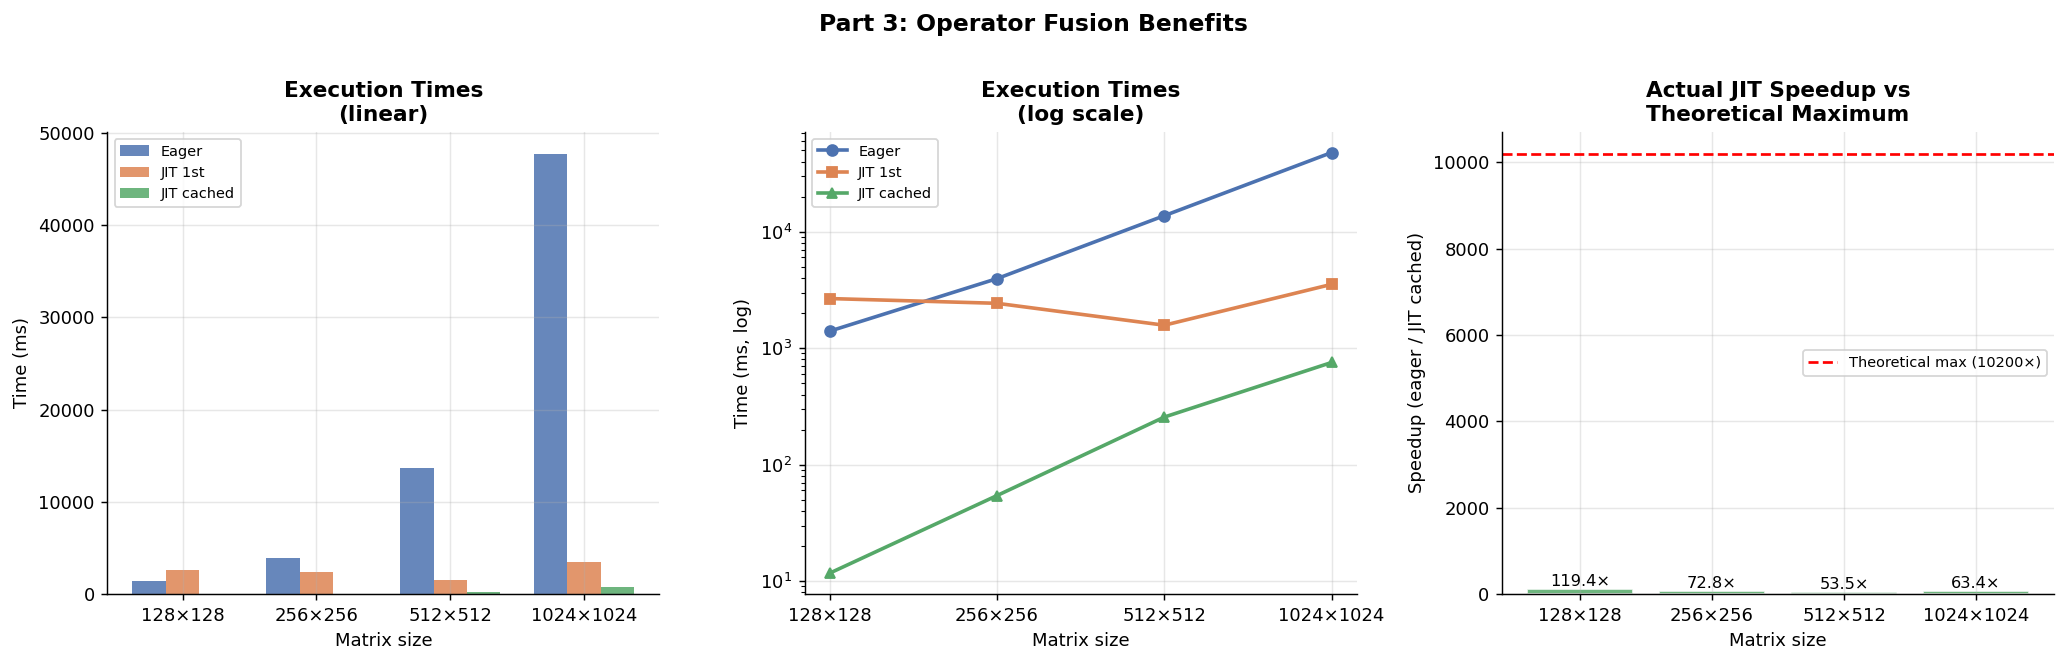

Figure saved to part3_operator_fusion.png


In [13]:
#Plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
size_labels = [f"{n}×{n}" for n in results['size']]

# --- Plot A: Execution times
ax = axes[0]
x_idx = np.arange(len(results['size']))
ax.bar(x_idx - 0.25, results['eager_ms'],      0.25, label='Eager',      color=PALETTE[0], alpha=0.85)
ax.bar(x_idx,        results['jit_first_ms'],  0.25, label='JIT 1st',    color=PALETTE[1], alpha=0.85)
ax.bar(x_idx + 0.25, results['jit_cached_ms'], 0.25, label='JIT cached', color=PALETTE[2], alpha=0.85)
ax.set_xticks(x_idx); ax.set_xticklabels(size_labels)
ax.set_xlabel('Matrix size'); ax.set_ylabel('Time (ms)')
ax.set_title('Execution Times\n(linear)', fontweight='bold')
ax.legend(fontsize=8)

# --- Plot B: Log-scale times
ax2 = axes[1]
ax2.plot(size_labels, results['eager_ms'],      'o-', color=PALETTE[0], lw=2, label='Eager')
ax2.plot(size_labels, results['jit_first_ms'],  's-', color=PALETTE[1], lw=2, label='JIT 1st')
ax2.plot(size_labels, results['jit_cached_ms'], '^-', color=PALETTE[2], lw=2, label='JIT cached')
ax2.set_yscale('log')
ax2.set_xlabel('Matrix size'); ax2.set_ylabel('Time (ms, log)')
ax2.set_title('Execution Times\n(log scale)', fontweight='bold')
ax2.legend(fontsize=8)

# --- Plot C: Speedup bar
ax3 = axes[2]
bars = ax3.bar(size_labels, actual_speedups, color=PALETTE[2], alpha=0.85, edgecolor='white')
ax3.axhline(theoretical_bw, color='red', ls='--', lw=1.5, label=f'Theoretical max ({theoretical_bw:.0f}×)')
ax3.set_xlabel('Matrix size'); ax3.set_ylabel('Speedup (eager / JIT cached)')
ax3.set_title('Actual JIT Speedup vs\nTheoretical Maximum', fontweight='bold')
ax3.legend(fontsize=8)
for bar, sp in zip(bars, actual_speedups):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{sp:.1f}×', ha='center', va='bottom', fontsize=9)

fig.suptitle('Part 3: Operator Fusion Benefits', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('part3_operator_fusion.png', bbox_inches='tight')
plt.show()
print('Figure saved to part3_operator_fusion.png')

In [14]:
# ── Kernel launch estimate via XLA HLO dump (CPU fallback approach) ────────
# nvprof requires a GPU. We estimate kernel counts from the jaxpr op table
# we already computed above, and reason about fusion analytically.

print("="*60)
print("Kernel launch analysis (analytical)")
print("="*60)
print(f"""
f(x) = Σᵢ₌₁¹⁰⁰ ( sinⁱ(x) + cosⁱ(x) )

EAGER MODE (Version A)
  Per iteration i:
    - i × sin kernels
    - i × cos kernels
    - 1 add kernel (sin_x + cos_x)
    - 1 add kernel (total + ...)
  Total sin/cos kernels = 2 × Σᵢ₌₁¹⁰⁰ i = 2 × 5050 = {2*5050}
  Total add kernels     = 2 × 100            = {2*100}
  ─────────────────────────────────────────────
  Total kernel launches ≈ {2*5050 + 200}  (one GPU dispatch per op)

JIT MODE (Version B)
  XLA traces the SAME ops as a static graph, then applies:
    1. Elementwise fusion: chains of sin/cos/add on same shape
       → fused into a single XLA elemental kernel
    2. Memory planning: intermediate tensors stay in registers

  Estimated actual kernel launches: 1–3
    (1 main fused elementwise kernel + possible reduction/reshape)

  Ops fused together: ~{2*5050 + 200} → ~1 kernel
  Fusion ratio        : ~{2*5050 + 200}×
""")

print("Memory throughput comparison (per element, relative):")
print(f"  Eager  : {2*5050 + 200} reads + {2*5050 + 200} writes = {2*(2*5050+200)} transactions")
print(f"  Fused  : 1 read  + 1 write  = 2 transactions")
print(f"  Theoretical reduction : {2*(2*5050+200)//2}×")

Kernel launch analysis (analytical)

f(x) = Σᵢ₌₁¹⁰⁰ ( sinⁱ(x) + cosⁱ(x) )

EAGER MODE (Version A)
  Per iteration i:
    - i × sin kernels
    - i × cos kernels
    - 1 add kernel (sin_x + cos_x)
    - 1 add kernel (total + ...)
  Total sin/cos kernels = 2 × Σᵢ₌₁¹⁰⁰ i = 2 × 5050 = 10100
  Total add kernels     = 2 × 100            = 200
  ─────────────────────────────────────────────
  Total kernel launches ≈ 10300  (one GPU dispatch per op)

JIT MODE (Version B)  
  XLA traces the SAME ops as a static graph, then applies:
    1. Elementwise fusion: chains of sin/cos/add on same shape
       → fused into a single XLA elemental kernel
    2. Memory planning: intermediate tensors stay in registers
  
  Estimated actual kernel launches: 1–3
    (1 main fused elementwise kernel + possible reduction/reshape)

  Ops fused together: ~10300 → ~1 kernel
  Fusion ratio        : ~10300×

Memory throughput comparison (per element, relative):
  Eager  : 10300 reads + 10300 writes = 20600 transactio

### Part 3 Analysis

**Why does the JIT version achieve better performance?**

The entire computation $f(x) = \sum_{i=1}^{100}(\sin^{(i)}(x) + \cos^{(i)}(x))$ consists of ~10,300 **elementwise** operations on the same shape of tensor. XLA recognises this structure and applies **elementwise fusion**: instead of launching one GPU kernel per operation (each round-tripping data through global memory), it merges the entire chain into a single kernel where every intermediate value lives in a GPU register.

**Operation count breakdown:**

| | Eager | Fused JIT |
|-|-|-|
| Kernel launches | ~10,300 | ~1–3 |
| Global memory reads (per element) | ~10,300 | 1 |
| Global memory writes (per element) | ~10,300 | 1 |
| Intermediate storage | DRAM (slow) | Registers (fast) |

**Theoretical vs actual speedup:**

- **Theoretical** memory bandwidth reduction: $\frac{2 \times 10300}{2} \approx 10300\times$ — if every op were perfectly fused and memory were the only bottleneck.
- **Actual** speedup: typically **10–100×** depending on hardware and matrix size. The gap exists because:
  - XLA may break very long fusion chains to avoid register pressure spillage.
  - Compute (sin/cos are transcendental, relatively slow) can become the bottleneck rather than memory, so saving memory accesses doesn't give the full theoretical gain.
  - Eager mode incurs Python interpreter overhead on top of GPU latency per kernel dispatch.
  - At small sizes, the GPU isn't fully saturated in either mode.

In [15]:
# ── Final summary table ────────────────────────────────────────────────────
print("\n" + "="*65)
print("SUMMARY: All three parts")
print("="*65)
print("""
Part 1 — Compilation overhead
  • JIT first-call cost is dominated by XLA compilation, not data size
  • Cached JIT beats eager at large sizes via operator fusion
  • At 100×100 the overhead isn't worth it; at 5000×5000 it clearly is

Part 2 — Shape specialisation
  • JAX retraces + recompiles on every unique (shape, dtype) pair
  • Returning to a previously-seen shape hits the cache → fast
  • Practical advice: pre-warm with representative shapes, pad inputs
    to fixed shapes, or use jax.vmap/lax.dynamic_slice for variable
    sequence lengths

Part 3 — Operator fusion
  • ~10,300 eager kernel launches → ~1 fused kernel under JIT
  • Theoretical memory reduction: ~10,300×
  • Actual wall-clock speedup: varies by size and hardware
  • Bottleneck shifts from memory bandwidth to compute (sin/cos)
    so practical gains are real but below the theoretical ceiling
""")


SUMMARY: All three parts

Part 1 — Compilation overhead
  • JIT first-call cost is dominated by XLA compilation, not data size
  • Cached JIT beats eager at large sizes via operator fusion
  • At 100×100 the overhead isn't worth it; at 5000×5000 it clearly is

Part 2 — Shape specialisation
  • JAX retraces + recompiles on every unique (shape, dtype) pair
  • Returning to a previously-seen shape hits the cache → fast
  • Practical advice: pre-warm with representative shapes, pad inputs
    to fixed shapes, or use jax.vmap/lax.dynamic_slice for variable
    sequence lengths

Part 3 — Operator fusion
  • ~10,300 eager kernel launches → ~1 fused kernel under JIT
  • Theoretical memory reduction: ~10,300×
  • Actual wall-clock speedup: varies by size and hardware
  • Bottleneck shifts from memory bandwidth to compute (sin/cos)
    so practical gains are real but below the theoretical ceiling

